# RFM Customer Segmentation — Online Retail Dataset

**Goal:** Segment customers by purchase behavior (Recency, Frequency, Monetary value) to identify who drives the business and who's at risk of churning.

**Dataset:** UCI Online Retail Dataset — transactions from a UK-based online gift retailer, Dec 2010–Dec 2011 (~540K line items).

**Method:** Classic RFM analysis — score each customer on Recency (days since last purchase), Frequency (number of distinct orders), and Monetary value (total spend), then bucket them into business-meaningful segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('online_retail.csv', parse_dates=['InvoiceDate'])
print(df.shape)
df.head()

(531282, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 531282 entries, 0 to 531281
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    531282 non-null  int64         
 1   StockCode    531282 non-null  str           
 2   Description  531282 non-null  str           
 3   Quantity     531282 non-null  int64         
 4   InvoiceDate  531282 non-null  datetime64[us]
 5   UnitPrice    531282 non-null  float64       
 6   CustomerID   531282 non-null  float64       
 7   Country      531282 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 32.4 MB


## 2. Data Cleaning

Before computing RFM, we need to deal with: duplicate rows, transactions with no real `CustomerID` (can't attribute to a customer), and rows with zero/negative `UnitPrice` (bad entries, not real sales).

In [4]:
print("Duplicates:", df.duplicated().sum())
print("CustomerID == 0 (missing/unknown customer):", (df['CustomerID'] == 0).sum())
print("UnitPrice <= 0 (bad/free entries):", (df['UnitPrice'] <= 0).sum())

Duplicates: 5231
CustomerID == 0 (missing/unknown customer): 133358
UnitPrice <= 0 (bad/free entries): 1179


In [5]:
before = len(df)

df = df.drop_duplicates()
df = df[df['CustomerID'] != 0]          # no real customer attached
df = df[df['UnitPrice'] > 0]            # drop zero/negative price rows
df = df[df['Quantity'] > 0]             # safety check

df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

after = len(df)
print(f"Rows dropped: {before - after} ({(before-after)/before*100:.1f}%)")
print("Remaining rows:", after)

Rows dropped: 138590 (26.1%)
Remaining rows: 392692


## 3. Calculate RFM Metrics

For each customer:
- **Recency** — days since their most recent purchase (relative to one day after the dataset's last transaction, used as our "today")
- **Frequency** — number of distinct invoices (orders) they placed
- **Monetary** — total amount they spent

In [6]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date (reference 'today'):", snapshot_date)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.describe()

Snapshot date (reference 'today'): 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


## 4. Score Customers (Quartiles, 1-4)

Each metric is split into 4 quartiles. For Recency, **lower is better** (bought more recently), so the scoring is reversed — a customer in the "most recent" quartile gets a 4, not a 1.

In [7]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,4,6
1,12347,2,7,4310.00,4,4,4,12
2,12348,75,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,3,1,4,8
4,12350,310,1,334.40,1,1,2,4


## 5. Segment Customers

Combined RFM score (range 3-12) is bucketed into 5 business-meaningful tiers:

| Score | Segment |
|---|---|
| 10-12 | Champions - bought recently, often, and spend the most |
| 8-9 | Loyal Customers - solid, consistent buyers |
| 6-7 | Potential Loyalists - decent recent activity, room to grow |
| 4-5 | At Risk - used to buy, haven't in a while |
| 3 | Hibernating / Lost - low on all three dimensions |

In [8]:
def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)
rfm['Segment'].value_counts()

Segment
Champions              1267
At Risk                 991
Potential Loyalists     935
Loyal Customers         845
Hibernating / Lost      300
Name: count, dtype: int64

## 6. Visualize

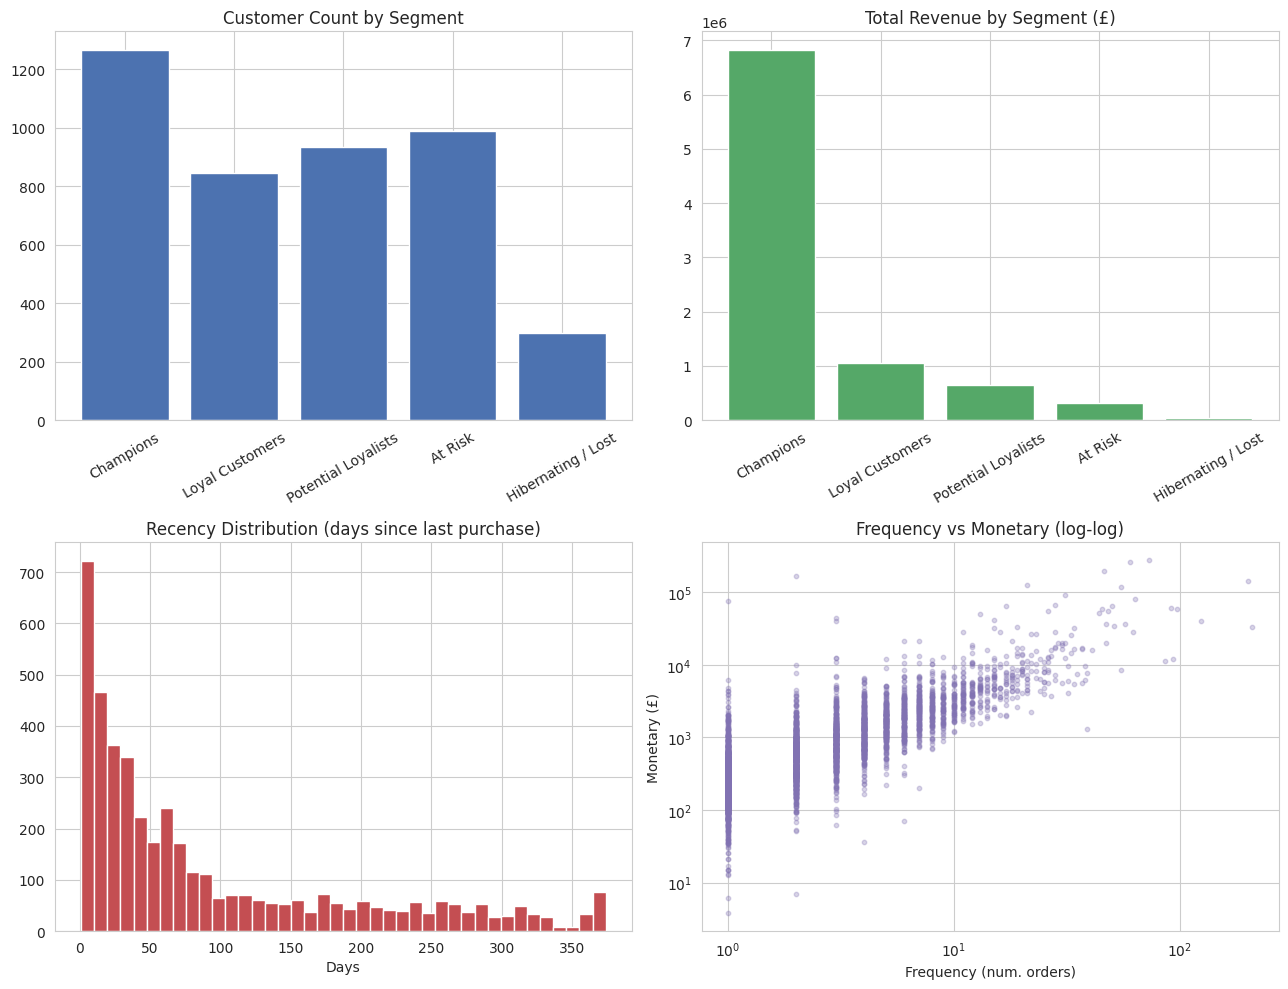

In [9]:
order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Hibernating / Lost']
seg_counts = rfm['Segment'].value_counts().reindex(order)
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().reindex(order)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].bar(seg_counts.index, seg_counts.values, color='#4C72B0')
axes[0, 0].set_title('Customer Count by Segment')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].bar(seg_revenue.index, seg_revenue.values, color='#55A868')
axes[0, 1].set_title('Total Revenue by Segment (£)')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].hist(rfm['Recency'], bins=40, color='#C44E52')
axes[1, 0].set_title('Recency Distribution (days since last purchase)')
axes[1, 0].set_xlabel('Days')

axes[1, 1].scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.3, s=10, c='#8172B2')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Frequency vs Monetary (log-log)')
axes[1, 1].set_xlabel('Frequency (num. orders)')
axes[1, 1].set_ylabel('Monetary (£)')

plt.tight_layout()
plt.savefig('rfm_charts.png', dpi=120)
plt.show()

## 7. Key Numbers

In [10]:
print("Total customers analyzed:", len(rfm))
print()
print("Segment revenue contribution:")
print(seg_revenue)
print()
print("Segment revenue %:")
print((seg_revenue / seg_revenue.sum() * 100).round(1))
print()
champions_pct_customers = (rfm['Segment']=='Champions').mean()*100
champions_pct_revenue = seg_revenue['Champions']/seg_revenue.sum()*100
print(f"Champions: {champions_pct_customers:.1f}% of customers, {champions_pct_revenue:.1f}% of revenue")

Total customers analyzed: 4338

Segment revenue contribution:
Segment
Champions              6827235.770
Loyal Customers        1051599.981
Potential Loyalists     650529.152
At Risk                 309485.761
Hibernating / Lost       48358.230
Name: Monetary, dtype: float64

Segment revenue %:
Segment
Champions              76.8
Loyal Customers        11.8
Potential Loyalists     7.3
At Risk                 3.5
Hibernating / Lost      0.5
Name: Monetary, dtype: float64

Champions: 29.2% of customers, 76.8% of revenue


## 8. Insights

- **Champions make up ~29% of customers but generate ~77% of total revenue** — a small core of highly engaged customers drives the overwhelming majority of the business. Strong case for prioritizing retention spend (loyalty perks, early access, personal outreach) on this group over broad-based discounting.
- **Median customer has only 2 orders and ~£669 lifetime spend** — most customers are far from "Champion" status, meaning there's a large middle segment (Potential Loyalists, At Risk) worth targeted re-engagement campaigns to move up a tier.
- **"At Risk" (991 customers) contributes only 3.5% of revenue despite being the largest segment after Champions** — these are customers who used to be active but have gone quiet; a win-back campaign here is lower-cost than acquiring new customers and has a clear behavioral trigger (recency) to act on.
- **Hibernating/Lost customers (300, ~7%) contribute under 1% of revenue** — likely not worth heavy retention spend; better to deprioritize them in favor of the At Risk and Potential Loyalist segments.

## 9. Save Output

In [11]:
rfm_out = rfm.sort_values('RFM_Score', ascending=False)
rfm_out.to_csv('rfm_customer_segments.csv', index=False)
print("Saved rfm_customer_segments.csv")

Saved rfm_customer_segments.csv
